# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [2]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [3]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /Users/raniaratulangis./Desktop/uni/EE/EE 446/tinyml_env_setup_package/UCI HAR Dataset


## 3. Load the Data


In [4]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    X_train = np.loadtxt(root_dir / "train/X_train.txt", dtype=np.float32)
    y_train = np.loadtxt(root_dir / "train/y_train.txt", dtype=np.int32) - 1
    X_test = np.loadtxt(root_dir / "test/X_test.txt",  dtype=np.float32)
    y_test = np.loadtxt(root_dir / "test/y_test.txt",  dtype=np.int32) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [5]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [6]:

def build_teacher_model(input_dim, num_classes):
    # TODO:
    # Build a larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # TODO:
    # Build a smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               287744    
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                                 
Total params: 452742 (1.73 MB)
Trainable params: 452742 (1.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. Train the Teacher Model


In [7]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(
    #<--- Enter your code here --->#
    X_train, 
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=teacher_callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4249 - accuracy: 0.8152 - val_loss: 0.1898 - val_accuracy: 0.9205
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1608 - accuracy: 0.9344 - val_loss: 0.1349 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1035 - accuracy: 0.9568 - val_loss: 0.3600 - val_accuracy: 0.8674
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0951 - accuracy: 0.9641 - val_loss: 0.1684 - val_accuracy: 0.9368
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0953 - accuracy: 0.9611 - val_loss: 0.1574 - val_accuracy: 0.9327


### Teacher Training Curves


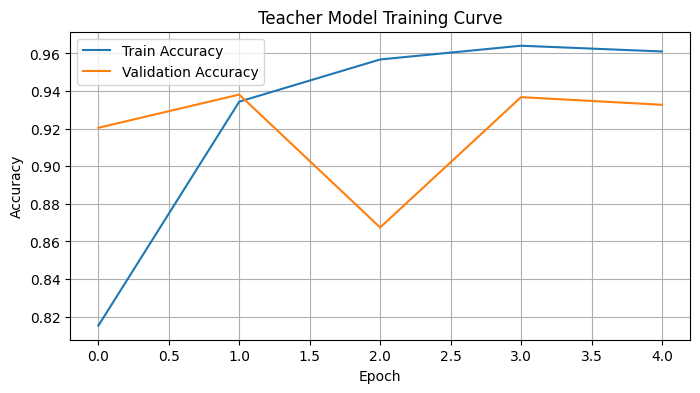

In [8]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


In [9]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline student using the hard labels only.
student_baseline_history = student_baseline_model.fit(
    #<--- Enter your code here --->#
    X_train, 
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 0s 877us/step - loss: 0.6947 - accuracy: 0.7674 - val_loss: 0.3262 - val_accuracy: 0.8906
Epoch 2/20
92/92 [==============================] - 0s 529us/step - loss: 0.2689 - accuracy: 0.9078 - val_loss: 0.2485 - val_accuracy: 0.9137
Epoch 3/20
92/92 [==============================] - 0s 500us/step - loss: 0.1705 - accuracy: 0.9441 - val_loss: 0.2348 - val_accuracy: 0.9157
Epoch 4/20
92/92 [==============================] - 0s 508us/step - loss: 0.1358 - accuracy: 0.9534 - val_loss: 0.1561 - val_accuracy: 0.9320
Epoch 5/20
92/92 [==============================] - 0s 504us/step - loss: 0.1074 - accuracy: 0.9621 - val_loss: 0.1495 - val_accuracy: 0.9279
Epoch 6/20
92/92 [==============================] - 0s 512us/step - loss: 0.0854 - accuracy: 0.9725 - val_loss: 0.2112 - val_accuracy: 0.9293
Epoch 7/20
92/92 [==============================] - 0s 495us/step - loss: 0.0778 - accuracy: 0.9747 - val_loss: 0.1267 - val_accuracy: 0.9436
Epoch 

## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [10]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 0s 962us/step - loss: 0.0790 - accuracy: 0.9716 - val_loss: 0.1455 - val_accuracy: 0.9381
Epoch 2/20
92/92 [==============================] - 0s 524us/step - loss: 0.0685 - accuracy: 0.9750 - val_loss: 0.1495 - val_accuracy: 0.9375
Epoch 3/20
92/92 [==============================] - 0s 511us/step - loss: 0.0531 - accuracy: 0.9818 - val_loss: 0.1693 - val_accuracy: 0.9415
Epoch 4/20
92/92 [==============================] - 0s 520us/step - loss: 0.0565 - accuracy: 0.9803 - val_loss: 0.1460 - val_accuracy: 0.9436
Epoch 5/20
92/92 [==============================] - 0s 500us/step - loss: 0.0524 - accuracy: 0.9806 - val_loss: 0.1451 - val_accuracy: 0.9388
Epoch 6/20
92/92 [==============================] - 0s 497us/step - loss: 0.0460 - accuracy: 0.9838 - val_loss: 0.1761 - val_accuracy: 0.9429
Epoch 7/20
92/92 [==============================] - 0s 519us/step - loss: 0.0653 - accuracy: 0.9767 - val_loss: 0.1604 - val_accuracy: 0.9470
Epoch 

## 9. Evaluate the Baseline Student Model


In [11]:

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # TODO:
        # 1. Obtain teacher predictions with training=False
        # 2. Compute student predictions inside GradientTape
        # 3. Compute student_loss using the hard labels
        # 4. Compute distillation_loss using softened teacher/student outputs
        # 5. Combine the two losses using alpha
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)

            student_loss = self.student_loss_fn(y, student_predictions)

            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            )

            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [12]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the distilled student.
distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
    
)


Epoch 1/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.7267 - student_loss: 0.7661 - distillation_loss: 0.0020 - val_accuracy: 0.8933 - val_student_loss: 0.1892
Epoch 2/20
92/92 [==============================] - 0s 808us/step - accuracy: 0.9017 - student_loss: 0.2847 - distillation_loss: 5.6165e-04 - val_accuracy: 0.9164 - val_student_loss: 0.0188
Epoch 3/20
92/92 [==============================] - 0s 836us/step - accuracy: 0.9265 - student_loss: 0.1928 - distillation_loss: 3.0474e-04 - val_accuracy: 0.9286 - val_student_loss: 0.0084
Epoch 4/20
92/92 [==============================] - 0s 806us/step - accuracy: 0.9500 - student_loss: 0.1404 - distillation_loss: 1.6997e-04 - val_accuracy: 0.9300 - val_student_loss: 0.0062
Epoch 5/20
92/92 [==============================] - 0s 801us/step - accuracy: 0.9602 - student_loss: 0.1126 - distillation_loss: 1.4439e-04 - val_accuracy: 0.9266 - val_student_loss: 0.0022
Epoch 6/20
92/92 [==============================] - 0s 7

## 11. Train the Distilled Student


In [13]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 0s 1ms/step - accuracy: 0.7172 - student_loss: 0.7448 - distillation_loss: 0.0019 - val_accuracy: 0.8906 - val_student_loss: 0.1097
Epoch 2/20
92/92 [==============================] - 0s 925us/step - accuracy: 0.9022 - student_loss: 0.2713 - distillation_loss: 5.1812e-04 - val_accuracy: 0.9198 - val_student_loss: 0.0150
Epoch 3/20
92/92 [==============================] - 0s 901us/step - accuracy: 0.9381 - student_loss: 0.1739 - distillation_loss: 2.5551e-04 - val_accuracy: 0.9252 - val_student_loss: 0.0105
Epoch 4/20
92/92 [==============================] - 0s 819us/step - accuracy: 0.9549 - student_loss: 0.1302 - distillation_loss: 1.7456e-04 - val_accuracy: 0.9286 - val_student_loss: 0.0053
Epoch 5/20
92/92 [==============================] - 0s 805us/step - accuracy: 0.9604 - student_loss: 0.1088 - distillation_loss: 1.4984e-04 - val_accuracy: 0.9307 - val_student_loss: 0.0017
Epoch 6/20
92/92 [==============================] - 0s 7

### Distillation Training Curves


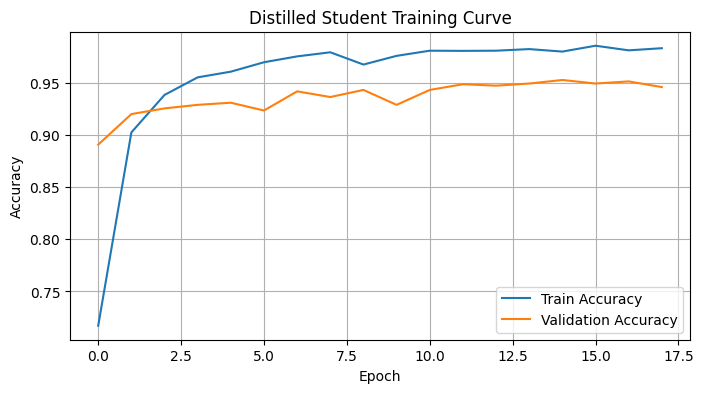

In [14]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9372

                    precision    recall  f1-score   support

           WALKING     0.9183    0.9738    0.9452       496
  WALKING_UPSTAIRS     0.9528    0.9002    0.9258       471
WALKING_DOWNSTAIRS     0.9499    0.9476    0.9487       420
           SITTING     0.9630    0.8473    0.9014       491
          STANDING     0.8600    0.9699    0.9117       532
            LAYING     1.0000    0.9777    0.9887       537

          accuracy                         0.9372      2947
         macro avg     0.9407    0.9361    0.9369      2947
      weighted avg     0.9401    0.9372    0.9372      2947



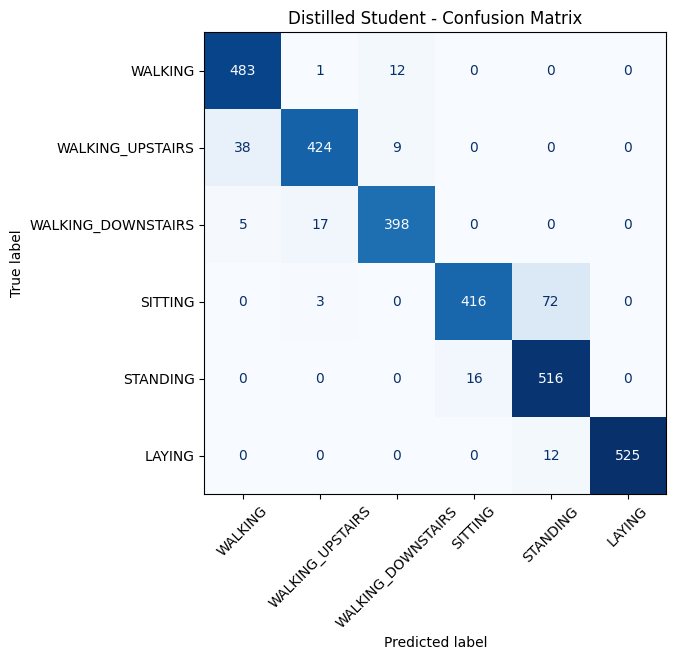

In [15]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [16]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input when the model expects int8/uint8 input.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output when needed.
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    # TODO:
    # Yield small batches from X_train for calibration.
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [17]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


## 15. Convert the Distilled Student to TensorFlow Lite


In [18]:
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.
student_for_pruning = build_student_model(num_features, num_classes)
student_for_pruning.set_weights(distilled_student.get_weights())

pruned_distilled_model = prune_low_magnitude(student_for_pruning, **pruning_params)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1
pruning_history = pruned_distilled_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/10
92/92 [==============================] - 1s 1ms/step - loss: 0.0369 - accuracy: 0.9878 - val_loss: 0.1300 - val_accuracy: 0.9483
Epoch 2/10
92/92 [==============================] - 0s 599us/step - loss: 0.0405 - accuracy: 0.9876 - val_loss: 0.1210 - val_accuracy: 0.9463
Epoch 3/10
92/92 [==============================] - 0s 588us/step - loss: 0.0509 - accuracy: 0.9874 - val_loss: 0.1133 - val_accuracy: 0.9504
Epoch 4/10
92/92 [==============================] - 0s 579us/step - loss: 0.0907 - accuracy: 0.9820 - val_loss: 0.1315 - val_accuracy: 0.9524
Epoch 5/10
92/92 [==============================] - 0s 580us/step - loss: 0.1320 - accuracy: 0.9645 - val_loss: 0.1429 - val_accuracy: 0.9565
Epoch 6/10
92/92 [==============================] - 0s 576us/step - loss: 0.2795 - accuracy: 0.9032 - val_loss: 0.1806 - val_accuracy: 0.9545
Epoch 7/10
92/92 [==============================] - 0s 577us/step - loss: 0.8345 - accuracy: 0.7533 - val_loss: 0.8842 - val_accuracy: 0.6526
Epoch 8/

## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [19]:

# TODO:
# Convert the pruned model with the pruning wrappers still attached.
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = strip_pruning(pruned_distilled_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp86dgtcmm/assets


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp86dgtcmm/assets
2026-04-24 18:34:13.865503: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-24 18:34:13.865523: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-24 18:34:13.865841: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp86dgtcmm
2026-04-24 18:34:13.866629: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-24 18:34:13.866632: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp86dgtcmm
2026-04-24 18:34:13.868722: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-24 18:34:13.869435: I tensorflow/cc/saved_model/load

INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpe3q74dpn/assets


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpe3q74dpn/assets


Pruned distilled model with mask accuracy: 0.9325
Pruned distilled model with mask size (KB): 304.31
Stripped sparse distilled model accuracy: 0.9325
Stripped sparse distilled model size (KB): 62.91


2026-04-24 18:34:14.185346: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-24 18:34:14.185356: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-24 18:34:14.185426: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpe3q74dpn
2026-04-24 18:34:14.185619: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-24 18:34:14.185621: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpe3q74dpn
2026-04-24 18:34:14.186072: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-24 18:34:14.191195: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpe3q74dpn
2026-04-

## 17. Convert the Pruned Distilled Student Before and After Stripping


In [20]:

# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp_nj5tr59/assets


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp_nj5tr59/assets
/Users/raniaratulangis./ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-24 18:35:06.471817: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-24 18:35:06.471829: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-24 18:35:06.471910: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp_nj5tr59
2026-04-24 18:35:06.472102: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-24 18:35:06.472105: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2y/vkd4

Stripped Sparse + INT8 Accuracy: 0.9308
Stripped Sparse + INT8 Size (KB): 33.52


## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [21]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmppfrf88bo/assets


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmppfrf88bo/assets


Stripped Sparse + INT8 Accuracy: 0.9308
Stripped Sparse + INT8 Size (KB): 33.52


/Users/raniaratulangis./ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-24 18:35:11.789373: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-24 18:35:11.789381: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-24 18:35:11.789449: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmppfrf88bo
2026-04-24 18:35:11.789628: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-24 18:35:11.789630: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmppfrf88bo
2026-04-24 18:35:11.790091: I tensorflow/cc/saved_model/loader

In [23]:
distilled_fp32_tflite = convert_to_tflite_fp32(distilled_student)
distilled_fp32_size_kb = save_binary_model(distilled_fp32_tflite, "distilled_student_fp32.tflite")
distilled_fp32_acc, distilled_fp32_preds = evaluate_tflite_model(distilled_fp32_tflite, X_test, y_test)

print(f"Distilled Student FP32 TFLite Accuracy: {distilled_fp32_acc:.4f}")
print(f"Distilled Student FP32 TFLite Size (KB): {distilled_fp32_size_kb:.2f}")

INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp58jm2wzg/assets


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp58jm2wzg/assets


Distilled Student FP32 TFLite Accuracy: 0.9372
Distilled Student FP32 TFLite Size (KB): 151.51


2026-04-24 18:37:44.957240: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-24 18:37:44.957251: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-24 18:37:44.957321: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp58jm2wzg
2026-04-24 18:37:44.957521: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-24 18:37:44.957524: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp58jm2wzg
2026-04-24 18:37:44.957990: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-24 18:37:44.963058: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp58jm2wzg
2026-04-

## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [24]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.937224,151.511719
1,Pruned Distilled TFLite (with mask),FP32,0.932474,304.312500
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.932474,62.906250
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.930777,33.523438


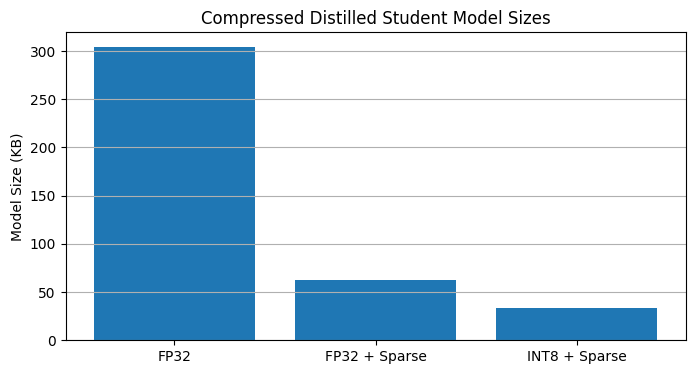

In [25]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


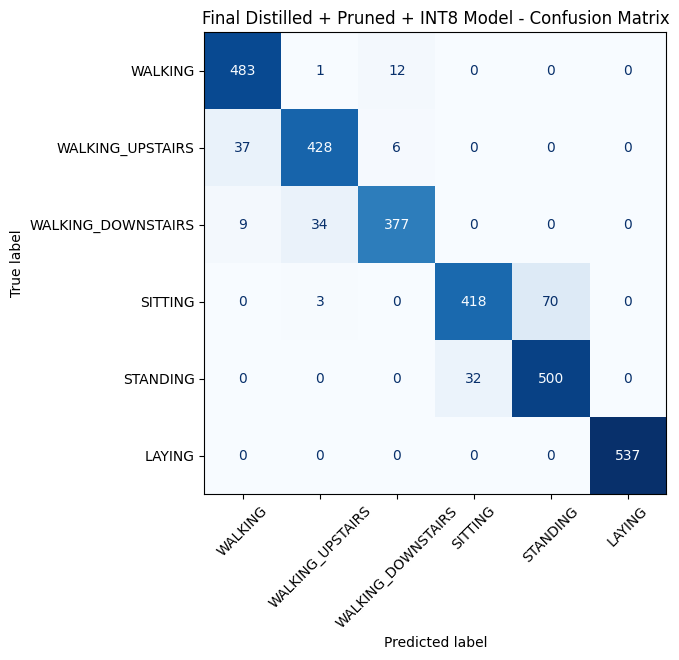

In [26]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**?
The baseline student performed slightly worse than the distilled student. Since it was only trained on hard labels (one-hot), it didn't get as much information to learn from, It only knew which class was correct, not how the teacher "thought" about the other classes.
2. Did **knowledge distillation** help the smaller model retain performance?
Yes: the distilled student was able to get closer to the teacher's accuracy even though it's a much smaller model. By learning from the teacher's soft probability outputs as opposed to just the ground truth labels, it picked up on subtle relationships between classes that can be easily missed.
3. What happened to the model size after **pruning** and after **INT8 quantization**?
Pruning didn't shrink the file that much since the zeroed-out weights are still stored as float32. On the other hand, once we stripped the pruning wrappers and enabled sparse optimization, the size started dropping. The biggest reduction came from INT8 quantization, which gave roughly a 4x size reduction.
4. Which model would you choose for **Arduino deployment**, and why?
I'd choose the final stripped sparse INT8 distilled student. It's the smallest of all the models built, uses integer ops which run well on hardware without a floating-point unit, and the distillation makes the model more accurate.
5. Why is the final **sparse INT8 model** a good TinyML deployment candidate?
It stacks three compression techniques that each tackle a different problem. Distillation keeps the accuracy high in a small model, pruning removes redundant weights to cut down memory usage, and INT8 quantization shrinks the file further while also speeding up inference. The end result is a model small enough to fit on an Arduino, fast enough to run in real time, and accurate enough to for real-world usage.


## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
